# Fourier vs B-spline basis: does the coarse-morphology conclusion survive a change of representation?

Mirrors the **stabilised nested CV** (`nested_cv_stabilised.ipynb`) exactly - same +/-1 s window, channel,
registration, penalty grid, fixed `n_components=5` and `C=1.0`, inner-5-fold **1-SE** selection, outer
5-fold, stratified on `certainty`, 10 repeats. **The basis is the only thing that changes.**

**Design choices (this run):**
- **Fourier tunes its own term count** over `[15, 21, 31, 41]` (odd; skfda requirement). On the 2 s window
  the effective low-pass cutoff is ~ `n/(2T)` = `n/4` Hz, so this spans ~3.75-10.25 Hz - bracketing and
  reaching *below* the ~7.5 Hz spline floor (nb=30). Selections are reported in **Hz** for a basis-agnostic
  comparison. (The EDA frequency-response cell established cutoff ~ n/(2T) for both bases, so counts map to
  bandwidth.)
- **Registration acts on grid samples, not the basis.** `SmoothRegister` smooths with the basis, resamples
  to a 100-pt grid, then Fisher-Rao warps *those samples*. So there is no "warping a periodic basis"; the only
  Fourier-specific risk is that edge ringing in the smoothed curve feeds the registration. The with/without-
  registration side check (fixed-setting) isolates that.

**Prediction:** since the signal lives in coarse shape and Fourier fit the transient region slightly better
than splines at low DoF, Fourier should be **comparable** to splines. Comparable -> corroborates the
coarse-morphology conclusion from a second representation. Notably worse -> the localised structure mattered
after all, which would sit awkwardly with the residual result.

Spline reference numbers below are the stabilised-run results (10 repeats).

In [1]:
import sys, time
from itertools import product
import numpy as np, pandas as pd, mne, matplotlib.pyplot as plt
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')
from joblib import Parallel, delayed
from skfda import FDataGrid
from skfda.preprocessing.smoothing import BasisSmoother
from skfda.preprocessing.registration import FisherRaoElasticRegistration
from skfda.preprocessing.dim_reduction import FPCA
from skfda.representation.basis import BSplineBasis, FourierBasis
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

sys.path.insert(0, str(Path('..') / 'src'))
from classify_loader import load_CSV
Path('../figures').mkdir(exist_ok=True)

CSV     = Path('..') / 'Kural_Dataset' / 'eeg_summary.csv'
EDF_DIR = Path('..') / 'Kural_Dataset' / 'Recordings'
SF, WIN_HALF, PEAK_HW = 500.0, 500, 50

# --- mirror stabilised config; only the basis + count grid differ ---
PENALTIES      = [0.01, 0.05, 0.1, 0.5]
FOURIER_COUNTS = [15, 21, 31, 41]     # ~3.75-10.25 Hz cutoff (n/2T)
SPLINE_COUNTS  = [30, 40, 60, 80]     # reference basis, same as stabilised
N_COMPONENTS, C_FIXED, N_REG = 5, 1.0, 100
OUTER_K, INNER_K, N_REPEATS, N_JOBS = 5, 5, 10, -1
MODES = ['amplitude', 'phase', 'both']
CERT_ORDER = ['negative', 'unclear_positive', 'clear_positive']

def cutoff_hz(count, TW=2.0): return count / (2 * TW)   # ~ n/(2T)

# stabilised-run spline results (10 repeats) for the side-by-side table
SPLINE_REF = {
    'amplitude': dict(auc=0.857, spec=0.854, sens_clear=0.814, sens_unclear=0.703),
    'phase':     dict(auc=0.606, spec=0.578, sens_clear=0.664, sens_unclear=0.500),
    'both':      dict(auc=0.827, spec=0.807, sens_clear=0.805, sens_unclear=0.634),
}

In [2]:
man = load_CSV(CSV)
curves = []
for _, r in man.iterrows():
    raw = mne.io.read_raw_edf(str(EDF_DIR / f"{r['file_id']}.edf"), preload=False, verbose=False)
    raw.drop_channels([c for c in raw.ch_names if not c.startswith('E ')])
    o = int(round(r['transient_onset_s'] * SF))
    d = raw.get_data(start=o - WIN_HALF, stop=o + WIN_HALF)
    ch = np.argmax(np.ptp(d[:, WIN_HALF - PEAK_HW:WIN_HALF + PEAK_HW], axis=1))
    curves.append(d[ch])
t  = (np.arange(2 * WIN_HALF) - WIN_HALF) / SF
DR = (t[0], t[-1])
fd = FDataGrid(np.stack(curves), t)
y  = man['label_binary'].to_numpy()
cert = man['certainty'].to_numpy()
tg = np.linspace(DR[0], DR[1], N_REG)
print(f"n={len(y)}  window=[{t[0]:.2f},{t[-1]:.2f}]s  epi={y.sum()} non={(y==0).sum()}")
print(f"Fourier counts {FOURIER_COUNTS} -> cutoffs {[round(cutoff_hz(c),1) for c in FOURIER_COUNTS]} Hz")

n=100  window=[-1.00,1.00]s  epi=54 non=46
Fourier counts [15, 21, 31, 41] -> cutoffs [3.8, 5.2, 7.8, 10.2] Hz


In [3]:
def make_basis(kind, count):
    if kind == 'spline':
        return BSplineBasis(domain_range=DR, n_basis=count, order=4)
    return FourierBasis(domain_range=DR, n_basis=count if count % 2 else count + 1)

def smooth_reg(kind, count, penalty, idx_fit, idx_tr, idx_te):
    """Smooth (kind,count) fit on idx_fit's smoother, register (penalty) with template from idx_tr,
    return aligned curves + warps for idx_tr and idx_te (grid samples)."""
    sm = BasisSmoother(make_basis(kind, count), return_basis=False)
    sm.fit(fd[idx_fit])
    g_tr = FDataGrid(sm.transform(fd[idx_tr])(tg).squeeze(-1), tg)
    g_te = FDataGrid(sm.transform(fd[idx_te])(tg).squeeze(-1), tg)
    reg = FisherRaoElasticRegistration(penalty=penalty); reg.fit(g_tr)
    a_tr = reg.transform(g_tr); w_tr = reg.warping_.data_matrix[:, :, 0].copy()
    a_te = reg.transform(g_te); w_te = reg.warping_.data_matrix[:, :, 0].copy()
    return a_tr.data_matrix[:, :, 0], w_tr, a_te.data_matrix[:, :, 0], w_te

def fpca_scores(mat_tr, mat_te):
    fp = FPCA(n_components=N_COMPONENTS); fp.fit(FDataGrid(mat_tr, tg))
    return fp.transform(FDataGrid(mat_tr, tg)), fp.transform(FDataGrid(mat_te, tg))

def feats(e, mode, s):
    if mode == 'amplitude': return e[f'amp_{s}']
    if mode == 'phase':     return e[f'ph_{s}']
    return np.hstack([e[f'amp_{s}'], e[f'ph_{s}']])

def select_1se(means, ses):
    best = max(means, key=means.get); thresh = means[best] - ses[best]
    cands = [k for k, m in means.items() if m >= thresh]
    return min(cands, key=lambda k: (-k[0], k[1]))   # higher penalty, then fewer terms (coarser)

def fit_pred(Xtr, Xte, ytr):
    sc = StandardScaler(); lr = LogisticRegression(C=C_FIXED, max_iter=1000, class_weight='balanced')
    lr.fit(sc.fit_transform(Xtr), ytr)
    return lr.predict_proba(sc.transform(Xte))[:, 1]

def compute_metrics(yp):
    yhat = (yp >= 0.5).astype(int)
    return dict(auc=roc_auc_score(y, yp),
                spec=np.mean(yhat[cert=='negative']==0),
                sens_clear=np.mean(yhat[cert=='clear_positive']==1),
                sens_unclear=np.mean(yhat[cert=='unclear_positive']==1))

In [4]:
def process_repeat(rep, kind, counts, modes):
    n = len(y); oof = {m: np.zeros(n) for m in modes}; params = {m: [] for m in modes}
    need_phase = any(m in ('phase', 'both') for m in modes)
    for fold, (tr, te) in enumerate(StratifiedKFold(OUTER_K, shuffle=True, random_state=rep)
                                    .split(np.arange(n), cert)):
        ytr = y[tr]
        inner = list(StratifiedKFold(INNER_K, shuffle=True, random_state=rep*100+fold)
                     .split(np.arange(len(tr)), cert[tr]))
        cache = {}                                   # shared across modes, built once
        for pen, nb in product(PENALTIES, counts):
            for i, (itr, ite) in enumerate(inner):
                a_tr, w_tr, a_te, w_te = smooth_reg(kind, nb, pen, tr[itr], tr[itr], tr[ite])
                e = {'y_tr': ytr[itr], 'y_te': ytr[ite]}
                e['amp_tr'], e['amp_te'] = fpca_scores(a_tr, a_te)
                if need_phase:
                    e['ph_tr'], e['ph_te'] = fpca_scores(w_tr, w_te)
                cache[(pen, nb, i)] = e
        for mode in modes:
            means, ses = {}, {}
            for pen, nb in product(PENALTIES, counts):
                au = []
                for i in range(INNER_K):
                    e = cache[(pen, nb, i)]
                    au.append(roc_auc_score(e['y_te'],
                              fit_pred(feats(e, mode, 'tr'), feats(e, mode, 'te'), e['y_tr'])))
                means[(pen, nb)] = np.mean(au); ses[(pen, nb)] = np.std(au, ddof=1)/np.sqrt(INNER_K)
            pen, nb = select_1se(means, ses)
            a_tr, w_tr, a_te, w_te = smooth_reg(kind, nb, pen, tr, tr, te)
            ftr, fte = [], []
            if mode in ('amplitude', 'both'):
                s = fpca_scores(a_tr, a_te); ftr.append(s[0]); fte.append(s[1])
            if mode in ('phase', 'both'):
                s = fpca_scores(w_tr, w_te); ftr.append(s[0]); fte.append(s[1])
            oof[mode][te] = fit_pred(np.hstack(ftr), np.hstack(fte), ytr)
            params[mode].append((pen, nb))
    return oof, params

def run_nested(kind, counts, modes, tag):
    t0 = time.time()
    out = Parallel(n_jobs=N_JOBS, verbose=5)(
        delayed(process_repeat)(rep, kind, counts, modes) for rep in range(N_REPEATS))
    res = {m: [] for m in modes}; oof_stk = {m: [] for m in modes}; par = {m: [] for m in modes}
    for oof, params in out:
        for m in modes:
            res[m].append(compute_metrics(oof[m])); oof_stk[m].append(oof[m]); par[m].extend(params[m])
    for m in modes:
        oof_stk[m] = np.array(oof_stk[m])
    print(f"[{tag}] done in {(time.time()-t0)/60:.1f} min  " +
          "  ".join(f"{m}={np.mean([r['auc'] for r in res[m]]):.3f}" for m in modes))
    return res, oof_stk, par

fou_res, fou_oof, fou_par = run_nested('fourier', FOURIER_COUNTS, MODES, 'fourier')
spl_res, spl_oof, spl_par = run_nested('spline', SPLINE_COUNTS, ['amplitude'], 'spline-amp')  # confusion ref + sanity

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of  10 | elapsed: 23.5min remaining: 35.2min
[Parallel(n_jobs=-1)]: Done   7 out of  10 | elapsed: 23.6min remaining: 10.1min
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed: 39.1min finished


[fourier] done in 39.1 min  amplitude=0.850  phase=0.561  both=0.838


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of  10 | elapsed: 71.4min remaining: 107.0min
[Parallel(n_jobs=-1)]: Done   7 out of  10 | elapsed: 71.4min remaining: 30.6min


[spline-amp] done in 90.8 min  amplitude=0.857


[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed: 90.8min finished


In [5]:
def spread(vals): return f"{np.mean(vals):.3f}  ({np.percentile(vals,10):.3f}-{np.percentile(vals,90):.3f})"
rows = []
for m in MODES:
    fa = [r['auc'] for r in fou_res[m]]
    rows.append({'condition': m,
                 'Fourier AUC': spread(fa),
                 'spline AUC': f"{SPLINE_REF[m]['auc']:.3f}",
                 'F spec': f"{np.mean([r['spec'] for r in fou_res[m]]):.2f}",
                 'F sens_clr': f"{np.mean([r['sens_clear'] for r in fou_res[m]]):.2f}",
                 'F sens_unc': f"{np.mean([r['sens_unclear'] for r in fou_res[m]]):.2f}",
                 'spl spec/clr/unc': f"{SPLINE_REF[m]['spec']:.2f}/{SPLINE_REF[m]['sens_clear']:.2f}/{SPLINE_REF[m]['sens_unclear']:.2f}"})
print(pd.DataFrame(rows).set_index('condition').to_string())
print(f"\nsanity: fresh spline-amplitude AUC = {np.mean([r['auc'] for r in spl_res['amplitude']]):.3f} "
      f"(stabilised reported 0.857)")
print(f"headline delta Fourier-amp vs spline-amp: "
      f"{np.mean([r['auc'] for r in fou_res['amplitude']]) - SPLINE_REF['amplitude']['auc']:+.3f}")

                    Fourier AUC spline AUC F spec F sens_clr F sens_unc spl spec/clr/unc
condition                                                                               
amplitude  0.850  (0.827-0.872)      0.857   0.86       0.79       0.67   0.85/0.81/0.70
phase      0.561  (0.503-0.645)      0.606   0.53       0.61       0.55   0.58/0.66/0.50
both       0.838  (0.803-0.880)      0.827   0.82       0.79       0.71   0.81/0.81/0.63

sanity: fresh spline-amplitude AUC = 0.857 (stabilised reported 0.857)
headline delta Fourier-amp vs spline-amp: -0.007


In [6]:
print("Selected Fourier term count across outer folds (count -> cutoff Hz):")
for m in MODES:
    cnts = [nb for _, nb in fou_par[m]]
    dist = {c: cnts.count(c) for c in sorted(set(cnts))}
    print(f"  {m:10s} " + "  ".join(f"{c}({cutoff_hz(c):.1f}Hz):{n}" for c, n in dist.items()))
    pens = [p for p, _ in fou_par[m]]
    print(f"             penalty: {{" + ", ".join(f'{p}:{pens.count(p)}' for p in sorted(set(pens))) + "}")
# modal settings (amplitude) for reconstruction + no-reg check
FMODE_CNT = max(set(nb for _, nb in fou_par['amplitude']), key=[nb for _, nb in fou_par['amplitude']].count)
FMODE_PEN = max(set(p for p, _ in fou_par['amplitude']), key=[p for p, _ in fou_par['amplitude']].count)
SMODE_CNT = max(set(nb for _, nb in spl_par['amplitude']), key=[nb for _, nb in spl_par['amplitude']].count)
SMODE_PEN = max(set(p for p, _ in spl_par['amplitude']), key=[p for p, _ in spl_par['amplitude']].count)
print(f"\nmodal amplitude settings -> fourier(count={FMODE_CNT}, pen={FMODE_PEN}), "
      f"spline(count={SMODE_CNT}, pen={SMODE_PEN})")

Selected Fourier term count across outer folds (count -> cutoff Hz):
  amplitude  15(3.8Hz):19  21(5.2Hz):11  31(7.8Hz):17  41(10.2Hz):3
             penalty: {0.01:7, 0.05:7, 0.1:15, 0.5:21}
  phase      15(3.8Hz):18  21(5.2Hz):14  31(7.8Hz):8  41(10.2Hz):10
             penalty: {0.01:6, 0.05:7, 0.1:14, 0.5:23}
  both       15(3.8Hz):16  21(5.2Hz):15  31(7.8Hz):15  41(10.2Hz):4
             penalty: {0.01:7, 0.05:13, 0.1:17, 0.5:13}

modal amplitude settings -> fourier(count=15, pen=0.5), spline(count=30, pen=0.1)


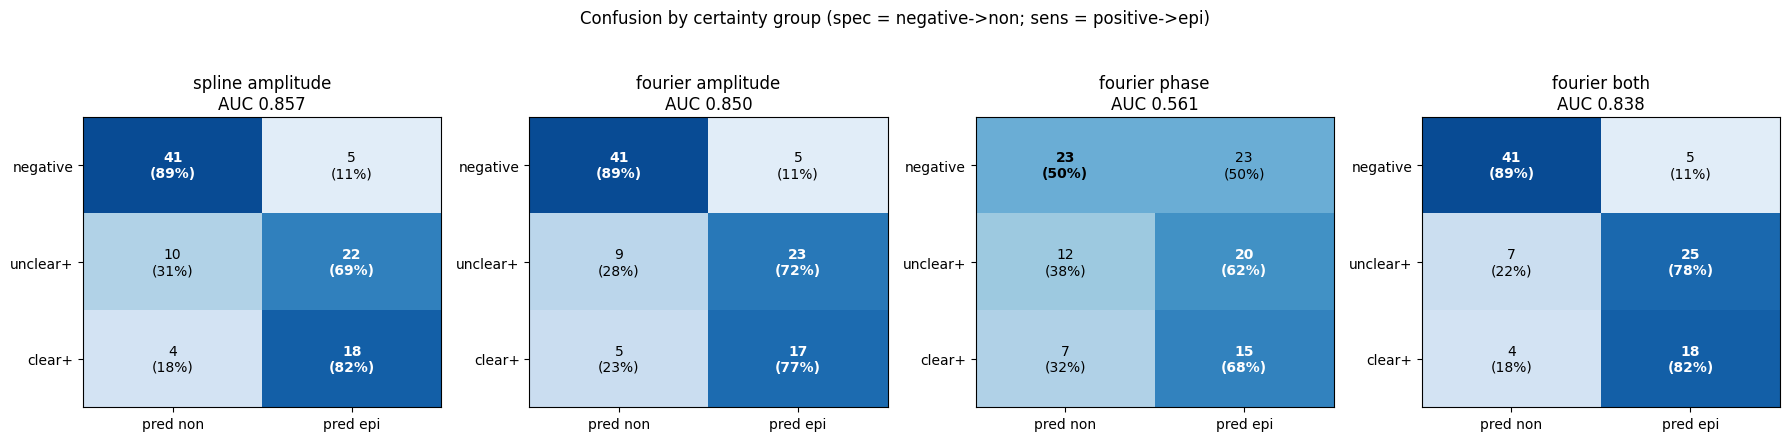

In [7]:
def confusion(mean_prob):
    pred = (mean_prob >= 0.5).astype(int); M = np.zeros((3, 2), int)
    for i, g in enumerate(CERT_ORDER):
        mask = cert == g; M[i, 0] = np.sum(pred[mask]==0); M[i, 1] = np.sum(pred[mask]==1)
    return M

panels = [('spline amplitude', spl_oof['amplitude'].mean(0), SPLINE_REF['amplitude']['auc'])] + \
         [(f'fourier {m}', fou_oof[m].mean(0), np.mean([r['auc'] for r in fou_res[m]])) for m in MODES]
fig, axes = plt.subplots(1, len(panels), figsize=(18, 4.2))
for ax, (title, mp, auc) in zip(axes, panels):
    M = confusion(mp); rates = M / M.sum(1, keepdims=True)
    ax.imshow(rates, cmap='Blues', vmin=0, vmax=1, aspect='auto')
    for i in range(3):
        for j in range(2):
            ok = (j == 0 and i == 0) or (j == 1 and i > 0)
            ax.text(j, i, f"{M[i,j]}\n({rates[i,j]:.0%})", ha='center', va='center',
                    fontweight='bold' if ok else 'normal', color='white' if rates[i,j] > 0.5 else 'black')
    ax.set_xticks([0,1]); ax.set_xticklabels(['pred non', 'pred epi'])
    ax.set_yticks([0,1,2]); ax.set_yticklabels(['negative', 'unclear+', 'clear+'])
    ax.set_title(f"{title}\nAUC {auc:.3f}")
plt.suptitle('Confusion by certainty group (spec = negative->non; sens = positive->epi)', y=1.04)
plt.tight_layout()
plt.savefig('../figures/fourier_confusion_matrices.png', dpi=800, bbox_inches='tight')
plt.show()

In [8]:
# --- with- vs without-registration, fixed-setting side check (amplitude only) ---
def fixed_amp_cv(kind, count, penalty, register, n_rep=10):
    aucs = []
    for rep in range(n_rep):
        oof = np.zeros(len(y))
        for tr, te in StratifiedKFold(5, shuffle=True, random_state=rep).split(np.arange(len(y)), cert):
            sm = BasisSmoother(make_basis(kind, count), return_basis=False); sm.fit(fd[tr])
            g_tr = FDataGrid(sm.transform(fd[tr])(tg).squeeze(-1), tg)
            g_te = FDataGrid(sm.transform(fd[te])(tg).squeeze(-1), tg)
            if register:
                reg = FisherRaoElasticRegistration(penalty=penalty); reg.fit(g_tr)
                mtr = reg.transform(g_tr).data_matrix[:, :, 0]; mte = reg.transform(g_te).data_matrix[:, :, 0]
            else:
                mtr, mte = g_tr.data_matrix[:, :, 0], g_te.data_matrix[:, :, 0]
            Xtr, Xte = fpca_scores(mtr, mte)
            oof[te] = fit_pred(Xtr, Xte, y[tr])
        aucs.append(roc_auc_score(y, oof))
    return np.array(aucs)

grid = [('spline', SMODE_CNT, SMODE_PEN), ('fourier', FMODE_CNT, FMODE_PEN)]
print("Amplitude, fixed modal settings, 10 repeats  (mean [p10-p90]):")
print(f"{'basis':8s} {'with reg':>22s} {'no reg':>22s} {'reg effect':>10s}")
for kind, cnt, pen in grid:
    wr = fixed_amp_cv(kind, cnt, pen, True); nr = fixed_amp_cv(kind, cnt, pen, False)
    print(f"{kind:8s} {spread(wr):>22s} {spread(nr):>22s} {np.mean(wr)-np.mean(nr):>+10.3f}")
print("\nIf Fourier trails spline only in the 'with reg' column, the issue is the registration")
print("interaction (edge-ringing fed to warping), not the basis itself.")

Amplitude, fixed modal settings, 10 repeats  (mean [p10-p90]):
basis                  with reg                 no reg reg effect
spline     0.887  (0.855-0.912)   0.723  (0.705-0.744)     +0.163
fourier    0.868  (0.848-0.892)   0.678  (0.663-0.698)     +0.190

If Fourier trails spline only in the 'with reg' column, the issue is the registration
interaction (edge-ringing fed to warping), not the basis itself.


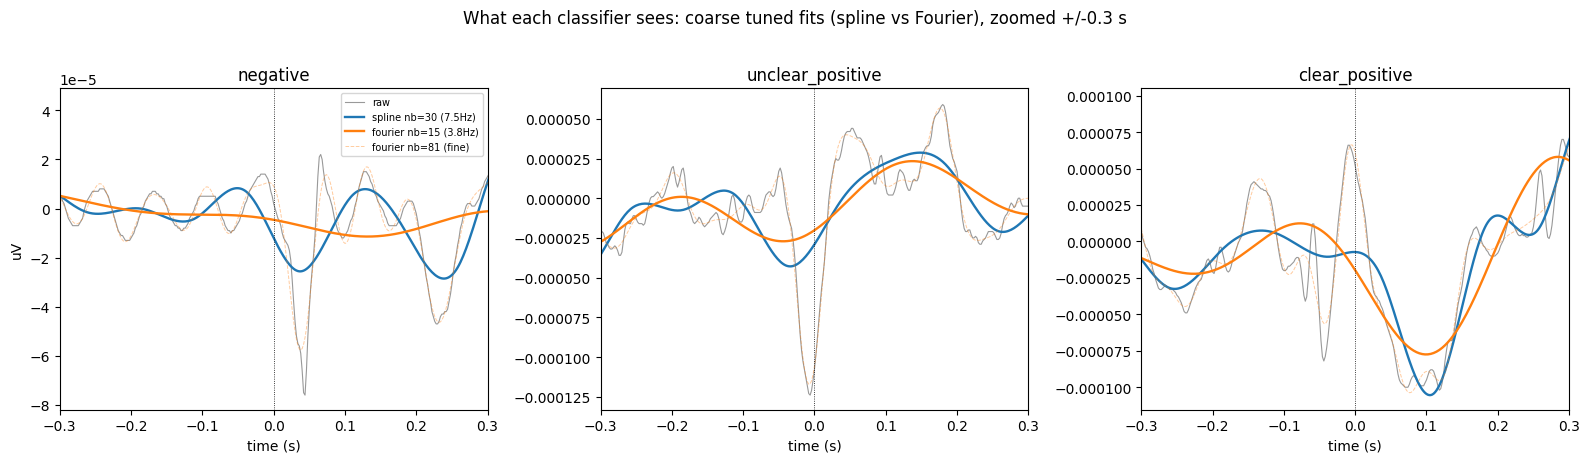

Fourier edge/interior residual RMS ratio (nb=15): 0.67  (>>1 would signal edge ringing)


In [9]:
# --- reconstruction figure: what each classifier actually sees (coarse tuned fits) ---
def fit_curve(curve, kind, count):
    return BasisSmoother(make_basis(kind, count), return_basis=False)\
        .fit_transform(FDataGrid(curve[None, :], t)).data_matrix[0, :, 0]

X = fd.data_matrix[:, :, 0]; near = np.abs(t) <= 0.1
ex = {g: [i for i in range(len(y)) if cert[i] == g]
      [int(np.argsort([np.ptp(X[i][near]) for i in range(len(y)) if cert[i] == g])[sum(cert==g)//2])]
      for g in CERT_ORDER}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, g in zip(axes, CERT_ORDER):
    c = X[ex[g]]
    ax.plot(t, c, color='0.6', lw=0.8, label='raw')
    ax.plot(t, fit_curve(c, 'spline', SMODE_CNT), color='C0', lw=1.7, label=f'spline nb={SMODE_CNT} ({cutoff_hz(SMODE_CNT):.1f}Hz)')
    ax.plot(t, fit_curve(c, 'fourier', FMODE_CNT), color='C1', lw=1.7, label=f'fourier nb={FMODE_CNT} ({cutoff_hz(FMODE_CNT):.1f}Hz)')
    ax.plot(t, fit_curve(c, 'fourier', 81), color='C1', lw=0.7, alpha=0.4, ls='--', label='fourier nb=81 (fine)')
    ax.axvline(0, color='k', ls=':', lw=0.6); ax.set_xlim(-0.3, 0.3)
    ax.set_title(g); ax.set_xlabel('time (s)')
axes[0].set_ylabel('uV'); axes[0].legend(fontsize=7)
plt.suptitle('What each classifier sees: coarse tuned fits (spline vs Fourier), zoomed +/-0.3 s', y=1.02)
plt.tight_layout()
plt.savefig('../figures/fourier_vs_spline_reconstruction.png', dpi=800, bbox_inches='tight')
plt.show()

# edge-ringing check: Fourier reconstruction error near the window edges vs interior
edge = np.abs(t) > 0.9; interior = np.abs(t) < 0.5
er = np.mean([np.sqrt(np.mean((X[i]-fit_curve(X[i],'fourier',FMODE_CNT))[edge]**2)) /
              (np.sqrt(np.mean((X[i]-fit_curve(X[i],'fourier',FMODE_CNT))[interior]**2))+1e-12) for i in range(len(y))])
print(f"Fourier edge/interior residual RMS ratio (nb={FMODE_CNT}): {er:.2f}  (>>1 would signal edge ringing)")

In [10]:
fa = np.mean([r['auc'] for r in fou_res['amplitude']]); sa = SPLINE_REF['amplitude']['auc']
d = fa - sa
print(f"Fourier amplitude AUC {fa:.3f}  vs  spline {sa:.3f}   delta {d:+.3f}")
if abs(d) <= 0.03:
    print("=> COMPARABLE. The coarse-morphology conclusion survives a change of representation:")
    print("   a global periodic basis reaches the same performance as local splines, corroborating")
    print("   that the signal is in the coarse shape, not localised fine structure.")
elif d < -0.03:
    print("=> Fourier NOTABLY WORSE. The localised structure mattered after all -- check whether the")
    print("   gap is registration-specific (no-reg table) before concluding against the coarse-signal story.")
else:
    print("=> Fourier BETTER. Unexpected; worth understanding what the periodic basis captures.")
print("\nAlso check: phase stays near-chance, and Fourier selected counts sit at the coarse (low-Hz) end.")

Fourier amplitude AUC 0.850  vs  spline 0.857   delta -0.007
=> COMPARABLE. The coarse-morphology conclusion survives a change of representation:
   a global periodic basis reaches the same performance as local splines, corroborating
   that the signal is in the coarse shape, not localised fine structure.

Also check: phase stays near-chance, and Fourier selected counts sit at the coarse (low-Hz) end.
